The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Intantibles start at: 3.25,  and tangibles at: 19.97
Intangibles end at:   10.14, and tangibles at: 12.20


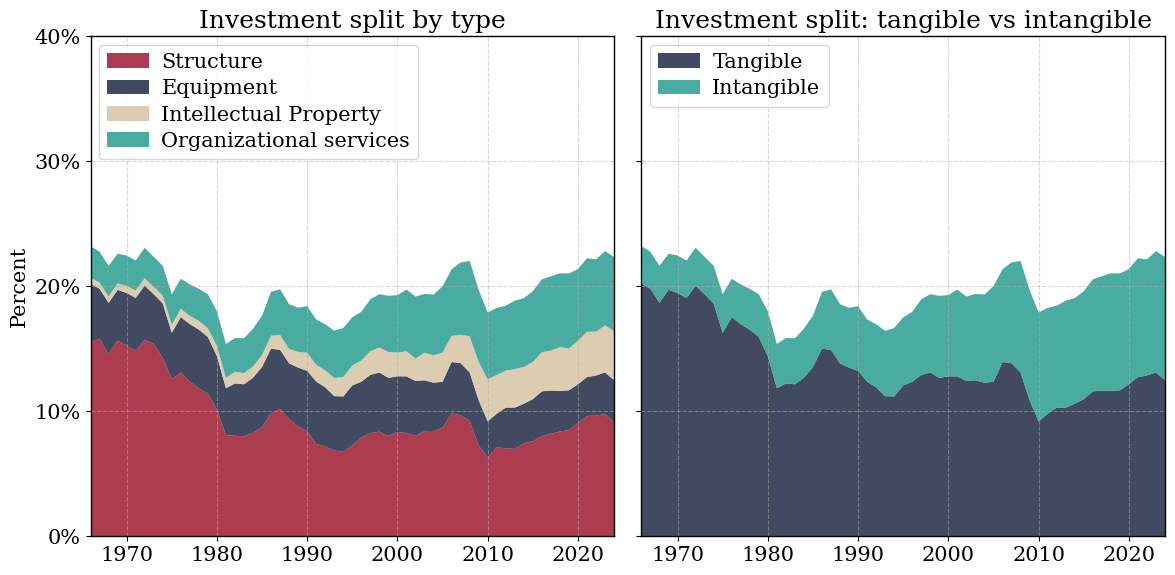

In [100]:
from py_files.setup import *
setup_notebook()

# %pip install git+https://github.com/alemartinello/dstapi
from IPython.display import display
from io import StringIO
from dstapi import DstApi
from functools import reduce

%run "3_2_investment_s.ipynb"

# 2. `Consolidated labour share`

**Data:** 
1. `NABP36` for Compensation of employees and GVA.
2. `RAS310` for educational decomposition.
3. `INDKP107` for economy wide wage split by education.
4. `LONS40` for wage per aggregate industry.

In [101]:
# 0. extraction helper
def code_token(x: pd.Index) -> pd.Series:
    s = pd.Series(x, dtype="string")
    return s.str.extract(r"^\s*([^ ]+)", expand=False)

# 1. extract codes
m_code = code_token(var_groups.mothers)          
s_code = code_token(var_groups.subs)     

# 2. mother letter of sub
s_mother = s_code.str[0]
groups = s_code.groupby(s_mother).apply(list).to_dict()

*`1. get aggregate labour income share by industry`*

In [102]:
NABP36 = DstApi('RAS310')

# 1. set up relevant inputs
transact = [
    'B1GD',  # B.1g Gross value added
    'D1D',   # D.1 Compensation of employees
]

# 2. set up fetch
params_e = {
    'table': 'NABP36',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'PRISENHED', 'values': ['V']},     # current prices (m. DKK)
        {'code': 'Tid', 'values': ['*']},
        {'code': 'BRANCHE', 'values': ['*']},
        {'code': 'TRANSAKT', 'values': transact}
        ]
}

# 3. get and clean
df_e_ = NABP36.get_data(params=params_e)
df_e_['INDHOLD'] = pd.to_numeric(df_e_['INDHOLD'], errors='coerce')

df_e = df_e_.pivot_table(
    index=['TID','BRANCHE'],
    columns='TRANSAKT',
    values='INDHOLD'
).reset_index()

df_e = df_e.rename(columns={
    'B.1g Gross value added'   : 'GVA',
    'D.1 Compensation of employees': 'e_comp'
})

# 4. compute labor share by industry
df_e['labor_share'] = df_e['e_comp'] / df_e['GVA'] * 100

df_e_slim = df_e[['TID','BRANCHE','labor_share','GVA']].copy()

# 5. drop total
df_e_slim = df_e_slim[~df_e_slim['BRANCHE'].eq('Total')].copy()

# 6. extract industry code
df_e_slim['branche_code'] = code_token(df_e_slim['BRANCHE'])

*`2. Educational split by industry`*

In [103]:
RAS310 = DstApi('RAS310')

# 2. set up fetch
params_em = {
    'table': 'RAS310',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'OMRÅDE', 'values': ['000']}, # all DK
        {'code': 'UDDANNELSE', 'values': ['*']},
        {'code': 'BRANCHE07', 'values': ['*']},
        {'code': 'ALDER', 'values': ['TOT']},
        {'code': 'KØN', 'values': ['TOT']},
        {'code': 'Tid', 'values': ['*']},
        ]
}

# 3. get and clean
df_em_ = RAS310.get_data(params=params_em)
df_em_['INDHOLD'] = pd.to_numeric(df_em_['INDHOLD'], errors='coerce')

df_em = df_em_.pivot_table(
    index=['TID','BRANCHE07'],
    columns='UDDANNELSE',
    values='INDHOLD'
).reset_index()

# 4. aggregate labour categories
noncollege = ["H10","H20","H30","H35"] 
college    = ["H40","H50","H60","H70","H80"]

df_em = df_em.rename(columns={
    'H10 Primary education'                         : 'H10',
    'H20 Upper secondary education'                 : 'H20',
    'H30 Vocational Education and Training (VET)'   : 'H30',
    'H35 Qualifying educational programs'           : 'H35',
    'H40 Short cycle higher education'              : 'H40',
    'H50 Vocational bachelors educations'           : 'H50',
    'H60 Bachelors programs'                        : 'H60',
    'H70 Masters programs'                          : 'H70',
    'H80 PhD programs'                              : 'H80',
    'H90 Not stated'                                : 'H90',
    'BRANCHE07'                                     : 'BRANCHE',                                 
})

df_em['non_college_s'] = (df_em[noncollege].sum(axis=1) + 0.5*df_em['H90']) / df_em['Total']
df_em['college_s'] = (df_em[college].sum(axis=1) + 0.5*df_em['H90']) / df_em['Total']

df_em_slim = df_em[['TID','BRANCHE','non_college_s','college_s']].copy()
df_em_slim["branche_code"] = df_em_slim["BRANCHE"].str.extract(r"^\s*([^ ]+)", expand=False)

df_em_slim = df_em_slim.loc[~df_em_slim["branche_code"].isin(['TOT','X'])].copy()

*deaggregate aggregates*

In [104]:
# for L
agg1  = "L Real estate activities"
subs1 = [
    "LA Real estate activities and renting of non-residential buildings",
    "LB Dwellings",
]

tmp = df_em_slim[df_em_slim["BRANCHE"].eq(agg1)].copy()

df_em_slim = pd.concat(
    [df_em_slim] + [tmp.assign(BRANCHE=s) for s in subs1],
    ignore_index=True
)

# for S
agg2  = "S Other service activities etc."
subs2 = [
    "SA Other service activities",
    "SB Activities of households as employers of domestic personnel",
]

tmp = df_em_slim[df_em_slim["BRANCHE"].eq(agg2)].copy()

df_em_slim = pd.concat(
    [df_em_slim] + [tmp.assign(BRANCHE=s) for s in subs2],
    ignore_index=True
)

# for CM
agg3 = "CM Manufacture of funiture and other manufacturing"
sub3 = "CM Manufacture of furniture and other manufacturing etc."

tmp = df_em_slim[df_em_slim["BRANCHE"].eq(agg3)].copy()
tmp["BRANCHE"] = sub3

df_em_slim = pd.concat([df_em_slim, tmp], ignore_index=True)

# for N
agg4 = "N Travel agent, cleaning, and other operationel services"
sub4 = "N Travel agents, cleaning, and other operationel services"

tmp = df_em_slim[df_em_slim["BRANCHE"].eq(agg4)].copy()
tmp["BRANCHE"] = sub4

df_em_slim = pd.concat([df_em_slim, tmp], ignore_index=True)

# delete aggregatex (except O)
aggs = [agg1, agg2, agg3, agg4]

df_em_slim = df_em_slim.loc[~df_em_slim["BRANCHE"].isin(aggs)].copy()

*`3. economy wide income split by education`*

In [105]:
INDKP107 = DstApi('INDKP107')
# INDKP107.tablesummary(language='en')
# INDKP107.variable_levels('INDKOMSTTYPE',language='en')

In [106]:
INDKP107 = DstApi('INDKP107')

# 1. types of income
inc_type = [
    '115', # Wages and salaries etc., total
    # '120', # Entrepreneurial income, total (not sure how much of this to include if any)
    # '125', # Received fees subject to labour market contr...
]
# 2. set up fetch
params_loen = {
    'table': 'INDKP107',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'OMRÅDE', 'values': ['000']},          # all DK
        {'code': 'UDDNIV', 'values': ['*']},
        {'code': 'INDKOMSTTYPE', 'values': inc_type},  
        {'code': 'ENHED', 'values': ['121']},           # Average income for people with type of income
        {'code': 'KOEN', 'values': ['MOK']},
        {'code': 'Tid', 'values': ['*']},
        ]
}

# 3. get and clean
df_loen_ = INDKP107.get_data(params=params_loen)
df_loen_['INDHOLD'] = pd.to_numeric(df_loen_['INDHOLD'], errors='coerce')

df_loen = df_loen_.pivot_table(
    index=['TID','INDKOMSTTYPE'],
    columns='UDDNIV',
    values='INDHOLD'
).reset_index()

# 4. aggregate income comp
df_loen = df_loen.rename(columns={
    '10 BASIC SCHOOL 8-10 grade'    : '10',
    '20+25 UPPER SECONDARY SCHOOL': '25',
    '35 VOCATIONAL EDUCATION': '35',
    '40 SHORT-CYCLE HIGHER EDUCATION': '40',
    '50+60 MEDIUM-CYCLE HIGHER EDUCATION, BACHLEOR': '60',
    '65 LONG-CYCLE HIGHER EDUCATION': '65',
})

noncollege_loen = ["10","25","35"]
college_loen    = ["40","60","65"]


df_loen['non_college_wage'] = df_loen[noncollege_loen].sum(axis=1)
df_loen['college_wage'] = df_loen[college_loen].sum(axis=1)

out = (df_loen
    .groupby('TID', as_index=False)
    .agg(
        non_college_wage = ('non_college_wage',
                            lambda s: s[df_loen.loc[s.index, 'INDKOMSTTYPE']
                                        .eq('4 Wages and salaries etc., total')]
                            .sum()),
        college_wage     = ('college_wage', 'sum'),
    )
)

# 5. sum per year
df_loen_year = out.groupby('TID').agg({
    'non_college_wage': 'sum',
    'college_wage': 'sum'
}).reset_index()

*`4. Combine`*, I now have (only data for all sources from 2008.):
1. `df_e`: the labour share per industry, $LS_i$.
2. `df_em`: educational shares by industry, $s_{i,C}$ and $s_{i,N}=1-s_{i,C}$.
3. `df_loen_year`: economy wide wage shifter by education, $\lambda = \omega_C/\omega_N$.

Thus, I find the effective share, i.e the share given the heterogenous wage between groups:
$$
    \tilde s_{i,C} = \frac{s_{i,C} \lambda}{s_{i,C}\lambda + (1-s_{s_{i,C}})}
$$

In [107]:

# 1. collect in one
df = (df_e_slim
      .merge(df_em_slim, on=["TID","BRANCHE"], how="inner")
      .merge(df_loen_year, on="TID", how="inner"))

# 2. wage shifter
df['lambda'] = df['college_wage'] / df['non_college_wage']

# 3. effective labour share
den = df["college_s"] * df["lambda"] + df["non_college_s"] * 1.0
df["wshare_college"] = (df["college_s"] * df["lambda"]) / den
df["wshare_noncol"]  = 1.0 - df["wshare_college"]

df["LS_college"] = df["labor_share"] * df["wshare_college"]
df["LS_noncol"]  = df["labor_share"] * df["wshare_noncol"] 

# 4. clean
df_final = df[["TID","BRANCHE",'labor_share',"LS_college","LS_noncol", 'GVA']].copy()
df_final['sanity'] = df_final['LS_college'] + df_final['LS_noncol'] - df_final['labor_share']

*define industry by type, either $C$ og $I$*

In [108]:
# 1. make list of 19 biggest parent classes in terms of consumption share in 2024
IO_parent_year['Iagg'] = IO_parent_year['intan_share'] + IO_parent_year['tan_share']

top_C = (IO_parent_year.sort_values(by='C_share', ascending=False)
         .head(20)['parent']
         .tolist())

top_I = (IO_parent_year.sort_values(by='Iagg', ascending=False)
         .head(12)['parent']
         .tolist())

print(top_C)
print(top_I)

['SB', 'LB', 'CD', 'QB', 'I', 'E', 'O', 'QA', 'A', 'SA', 'CA', 'H', 'K', 'D', 'R', 'P', 'JB', 'G', 'CB', 'CG']
['MA', 'CK', 'F', 'CF', 'CI', 'MB', 'MC', 'JC', 'CH', 'CJ', 'LA', 'CM']


In [109]:
# 2. set up mapping
df_final['code'] = df_final['BRANCHE'].str.split(' ').str[0]

# 3. C or I type
IO_parent_year['type'] = np.select(
    [IO_parent_year['parent'].isin(top_C),
     IO_parent_year['parent'].isin(top_I)],
    ['C', 'I'],
    default='x'
)

# easy fix to LS
# IO_parent_year = IO_parent_year.loc[~IO_parent_year["parent"].isin(["CF",'LA'])].copy()

# 4. map to type
df_final['type'] = df_final['code'].map(IO_parent_year.set_index('parent')['type'])

In [110]:
IO_parent_year

,index,parent,C_share,intan_share,tan_share,NX_share,final_use_share,sum_share,Iagg,type
0,2241,SB,100.0,0.0,0.0,0.0,0.2,100.0,0.0,C
1,2230,LB,100.0,0.0,0.0,0.0,8.9,100.0,0.0,C
2,2209,CD,100.0,0.0,0.0,-140.6,-0.1,241.0,0.0,C
3,2238,QB,99.9,0.1,0.0,0.5,5.7,100.0,0.1,C
4,2224,I,99.7,0.0,0.3,1.6,2.3,102.0,0.3,C
5,2220,E,99.4,0.0,0.6,29.9,1.0,130.0,0.6,C
6,2235,O,98.7,1.3,0.0,0.8,6.2,101.0,1.3,C
7,2237,QA,98.6,1.4,0.0,0.2,5.9,100.0,1.4,C
8,2204,A,97.8,0.0,2.2,155.5,0.5,256.0,2.2,C
9,2240,SA,97.2,2.7,0.1,-0.4,1.1,100.0,2.8,C


*plot*

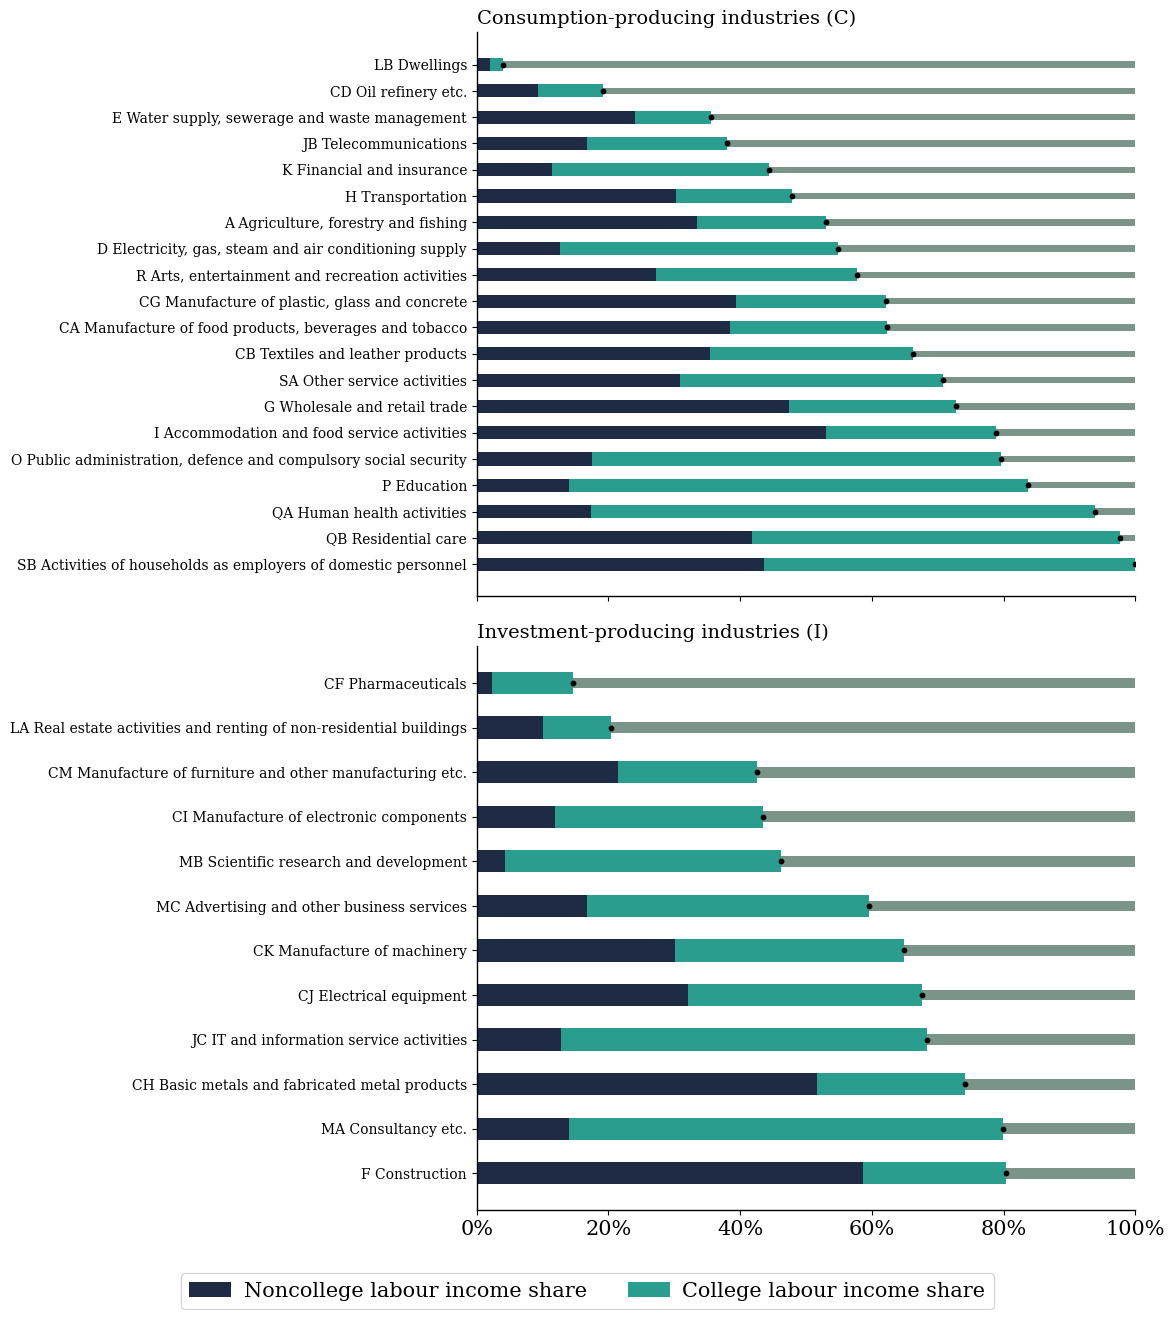

In [111]:
year  = 2024
d = df_final.loc[df_final["TID"] == year].copy()

# split blocks
cons = d.loc[d["type"] == "C"].copy()
inv  = d.loc[d["type"] == "I"].copy()

cons = cons.sort_values("labor_share", ascending=False)
inv  = inv.sort_values("labor_share", ascending=False)

# colours (change if you want)
c_col = "#2A9D8F"   # college
c_non = "#1F2A44"   # noncollege
c_cap = "#7a948a"   # residual to 100

# fig
fig, axes = plt.subplots(2, 1, figsize=(12, 14), sharex=True)

for ax, block, ttl in [
    (axes[0], cons, "Consumption-producing industries (C)"),
    (axes[1], inv,  "Investment-producing industries (I)"),
]:
    y = np.arange(len(block))

    noncol = block["LS_noncol"].to_numpy()
    col    = block["LS_college"].to_numpy()
    lab    = block["labor_share"].to_numpy()
    cap    = 100.0 - lab
    
    # stacked bars: noncollege + college + residual (capital share)
    ax.barh(y, noncol, color=c_non, 
            edgecolor="none", height=0.5, 
            label="Noncollege labour income share")
    
    ax.barh(y, col, left=noncol, color=c_col, 
            edgecolor="none", height=0.5, 
            label="College labour income share")
    
    ax.barh(y, cap, left=lab, color=c_cap, edgecolor="none", height=0.24)

    # dot at total labour share
    ax.scatter(lab, y, s=10, color="k", zorder=3)

    ax.set_yticks(y)
    ax.set_yticklabels(block["BRANCHE"], fontsize=10)
    ax.set_xlim(0, 100)
    ax.set_xticks(np.arange(0, 101, 20))
    ax.set_xticklabels([f"{v:d}%" for v in range(0, 101, 20)])

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.set_title(ttl, loc="left", fontsize=14)

# one legend for the whole figure (only the two labour components)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles[:2], labels[:2], loc="lower center", 
    ncol=2, frameon=True, bbox_to_anchor=(0.5, 0.02))

# fig.suptitle(f"Labour share split by education, {year}", y=0.995)
plt.tight_layout(rect=(0, 0.06, 1, 0.97))
plt.show()

*`5. economy wide labour income share by labourer type`* These I compute, given weights dependent on the industry to obtain weighted averages
$$
    w_i^C = \frac{GVA_i}{\sum_j GVA_j}d (\text{sector}_i \in C), 
        \quad w^I_i = \frac{GVA_i}{\sum_j GVA_j}d (\text{sector}_i \in I),
$$ 
then the aggregate labour shares are:
$$
    LS^C = \sum_i w_i^C LS_i, \quad L_S^I = \sum_i w_i^I LS_i.
$$

I use the labour share by type stored in `df_final` and the weights can be computed from `IO_parent`

*`6. wage by aggregate sector`*

In [112]:
# 1. dataset
LONS40 = DstApi('LONS40')

BRANCHE07_list = [
    'A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S'
]

# 2. set up fetch
params_sl = {
    'table': 'LONS40',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'BRANCHE07', 'values': BRANCHE07_list}, # all main
        {'code': 'SEKTOR', 'values': ['1000']},          # all sectors
        {'code': 'AFLOEN', 'values': ['TIFA']},          # all forms of pay
        {'code': 'LONGRP', 'values': ['LTOT']},          # Employee group total
        {'code': 'LØNMÅL', 'values': ['MDRSNIT']},       # STANDARDIZED MONTHLY EARNINGS
        {'code': 'KØN', 'values': ['MOK']},              # aggregate
        {'code': 'Tid', 'values': ['*']},                # all
        ]
}

# 3. get and clean
df_sl_ = LONS40.get_data(params=params_sl)
df_sl_['INDHOLD'] = pd.to_numeric(df_sl_['INDHOLD'], errors='coerce')
df_sl_["branche_letter"] = df_sl_["BRANCHE07"].str[0]

# 4. disaggregate by sub-industries
df = df_sl_.copy()
df["BRANCHE07"] = code_token(df["BRANCHE07"])        # overwrites full names -> codes
df["mother_code"] = df["BRANCHE07"].str[0]           # A..S (same as before, but now consistent)

# 5. disaggregate: clone mother rows to sub-codes (CA, JB, LB, ...)
new_rows = []

for mother, sub_codes in groups.items():
    sub_codes = [c for c in sub_codes if c != mother]   # only true subcats
    if not sub_codes:
        continue

    tmp = df.loc[df["BRANCHE07"].eq(mother)]
    if tmp.empty:
        continue

    new_rows.extend([tmp.assign(BRANCHE07=c) for c in sub_codes])

df_sl_disagg = pd.concat([df, *new_rows], ignore_index=True) if new_rows else df

# 6. drop the mother aggregates you expanded (keep O if you want)
expanded_mothers = [m for m, sc in groups.items() if any(c != m for c in sc)]
expanded_mothers = [m for m in expanded_mothers if m != "O"]  # keep O, like before

df_sl_disagg = df_sl_disagg.loc[~df_sl_disagg["BRANCHE07"].isin(expanded_mothers)].copy()

# 7. drop helper col
df_sl_disagg = df_sl_disagg.drop(columns=["mother_code"])
df_sl_disagg.sort_values(by=["TID", "BRANCHE07"], inplace=True)
df_sl_disagg = df_sl_disagg.rename(columns={"BRANCHE07": "branche_code"})

df_sl_disagg = df_sl_disagg.rename(columns={ 'INDHOLD': 'w_i_index' })

*merge sector wage levels with `df_final`*

In [113]:
# 8. merge with final dataset
df_final_m = df_final.copy()
df_final_m = df_final_m.merge(
    df_sl_disagg[["TID","branche_code","w_i_index"]], left_on=['TID','code'], right_on=['TID','branche_code']
    , how="left")

# 9. drop year before 2013 (no data for industry wages)
df_final_m = df_final_m[df_final_m["TID"] >= 2013].copy()

In [123]:
# 10. GVA weight within each (year, type) group
df_final_m["gva_w"] = df_final_m["GVA"] * df_final_m["w_i_index"]

# Normalise within (year, type)
df_final_m["w_adj"] = (df_final_m["gva_w"] 
                     / df_final_m.groupby(["TID", "type"])["gva_w"].transform("sum"))

# 11. weighted labor shares by (year, type)
agg = (df_final_m.groupby(["TID", "type"])
       .apply(lambda g: pd.Series({
           "LS":         np.sum(g["w_adj"] * g["labor_share"]),
           "LS_college": np.sum(g["w_adj"] * g["LS_college"]),
           "LS_noncol":  np.sum(g["w_adj"] * g["LS_noncol"]),
       }))
       .reset_index()
)

# 12. pivot so you get LS_C, LS_I as columns
agg_wide = agg.pivot(index="TID", columns="type", values=["LS", "LS_college", "LS_noncol"])
agg_wide.columns = [f"{val}_{typ}" for val, typ in agg_wide.columns]
agg_wide = agg_wide.reset_index()
agg = agg_wide.copy()

C:\Users\LinusLindquist\AppData\Local\Temp\ipykernel_11020\2984526423.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


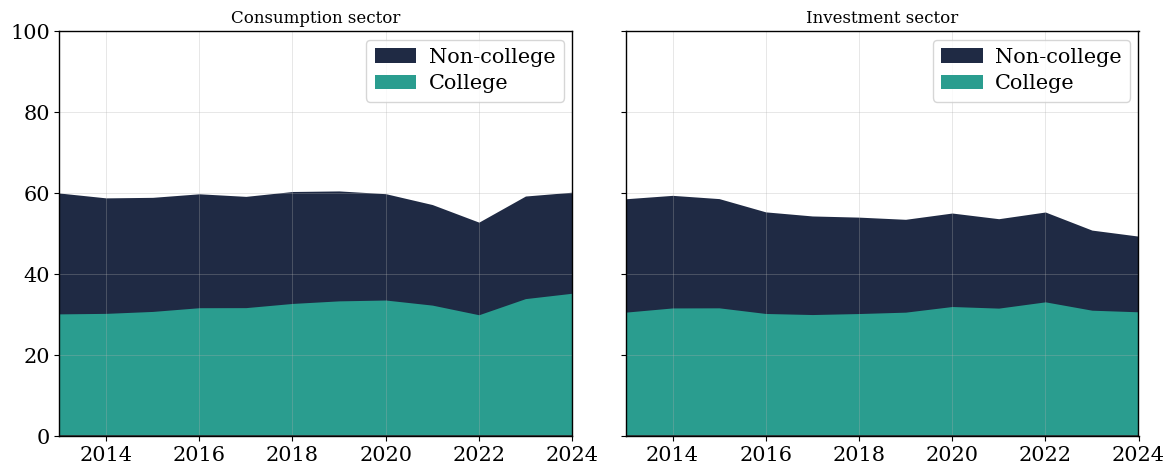

In [124]:
x = agg["TID"].to_numpy()

C_col = agg["LS_college_C"].to_numpy()
C_non = agg["LS_noncol_C"].to_numpy()
I_col = agg["LS_college_I"].to_numpy()
I_non = agg["LS_noncol_I"].to_numpy()

# if your series are in [0,1], uncomment:
# C_col, C_non, I_col, I_non = [s*100 for s in (C_col, C_non, I_col, I_non)]

# --- your vibe: crisp, minimal, crimson accent + neutral fills
fog   = "#E7E9EE"
steel = "#C9D2DF"
c_col = "#2A9D8F"   # college
c_non = "#1F2A44"   # noncollege


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

def pct(x, pos):  # y-axis formatter
    return f"{x:.0f}%"

ymax = np.nanmax([C_col + C_non, I_col + I_non])
ymax = float(np.ceil(max(ymax, 60) / 10) * 10)  # round up to nearest 10
ymax = min(max(ymax, 70), 100)                  # keep sane

for ax, col, non, panel_title in [
    (axes[0], C_col, C_non, "Consumption sector"),
    (axes[1], I_col, I_non, "Investment sector"),
]:
    top = col + non

    # background "total labor share" fill (neutral)
    ax.fill_between(x, 0, top, color=c_non, linewidth=0, label="Non-college")

    # college fill (crimson accent)
    ax.fill_between(x, 0, col, color=c_col, linewidth=0, label='College')

    # subtle baseline
    ax.axhline(0, color="0.2", linewidth=1.2)

    ax.set_title(panel_title, fontsize=12)
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, 100)
    
    # clean spines + ticks

    # minimalist grid (very faint)
    ax.grid(linewidth=0.6, alpha=0.35)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6))

    # in-panel labels (low-key)
    ax.legend()

# single figure title (also your style: understated)
plt.tight_layout()
plt.show()

*calibration output*

In [125]:
# 1. rename
out = (agg.rename(columns={
        "LS_college_C": "alpha2L",
        "LS_noncol_C" : "alpha1L",
        "LS_college_I": "beta2L",
        "LS_noncol_I" : "beta1L",
    })
    .assign(**{c: lambda d, c=c: d[c] / 100 for c in ["alpha1L","alpha2L","beta1L","beta2L"]})
)

# 2. print
print(out.iloc[-2][["TID","alpha1L","alpha2L","beta1L","beta2L"]])

TID        2023.000000
alpha1L       0.253319
alpha2L       0.339977
beta1L        0.197807
beta2L        0.311359
Name: 10, dtype: float64


*weighted by both industry share in sector and GVA.*

In [117]:
# 1. get sector weights
IO_GDP['I_agg'] = IO_GDP.intan + IO_GDP.tan
IO_GDP['C_agg'] = IO_GDP.C + IO_GDP.G
sec_w = IO_GDP[['TID','parent','I_agg','C_agg']]

# 2. merge with labour shares
df_s = df_final_m.merge(
    sec_w, left_on=['TID','code'], right_on=['TID','parent'], how='inner')

# 3. compute triple weights with wage adjustment (normalized)
df_s['w_C'] = (df_s['C_agg'] * df_s['GVA'] * df_s['w_i_index']) / \
    df_s.groupby('TID').apply(lambda g: (g['C_agg'] * g['GVA'] * g['w_i_index']).sum()).reindex(df_s['TID']).values

df_s['w_I'] = (df_s['I_agg'] * df_s['GVA'] * df_s['w_i_index']) / \
    df_s.groupby('TID').apply(lambda g: (g['I_agg'] * g['GVA'] * g['w_i_index']).sum()).reindex(df_s['TID']).values
    
# 4. labour shares as fractions
df_s['labor_share'] /= 100
df_s['LS_college']  /= 100
df_s['LS_noncol']   /= 100

# 5. weighted labour shares per year
agg = (df_s.groupby("TID")
       .apply(lambda g: pd.Series({
           "LS_C":         np.sum(g["w_C"] * g["labor_share"]),
           "LS_I":         np.sum(g["w_I"] * g["labor_share"]),
           "LS_college_C": np.sum(g["w_C"] * g["LS_college"]),
           "LS_noncol_C":  np.sum(g["w_C"] * g["LS_noncol"]),
           "LS_college_I": np.sum(g["w_I"] * g["LS_college"]),
           "LS_noncol_I":  np.sum(g["w_I"] * g["LS_noncol"]),
           
        #    "LS_college_I": np.sum(g["w_I"] * g["LS_college"]) +0.1, # actually a nice fix
        #    "LS_noncol_I":  np.sum(g["w_I"] * g["LS_noncol"])  -0.1, # but needs to be justified
       }))
       .reset_index()
)

C:\Users\LinusLindquist\AppData\Local\Temp\ipykernel_11020\1768957744.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_s.groupby('TID').apply(lambda g: (g['C_agg'] * g['GVA'] * g['w_i_index']).sum()).reindex(df_s['TID']).values
C:\Users\LinusLindquist\AppData\Local\Temp\ipykernel_11020\1768957744.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_s.groupby('TID').apply(lambda g: (g['I_agg'] * g[

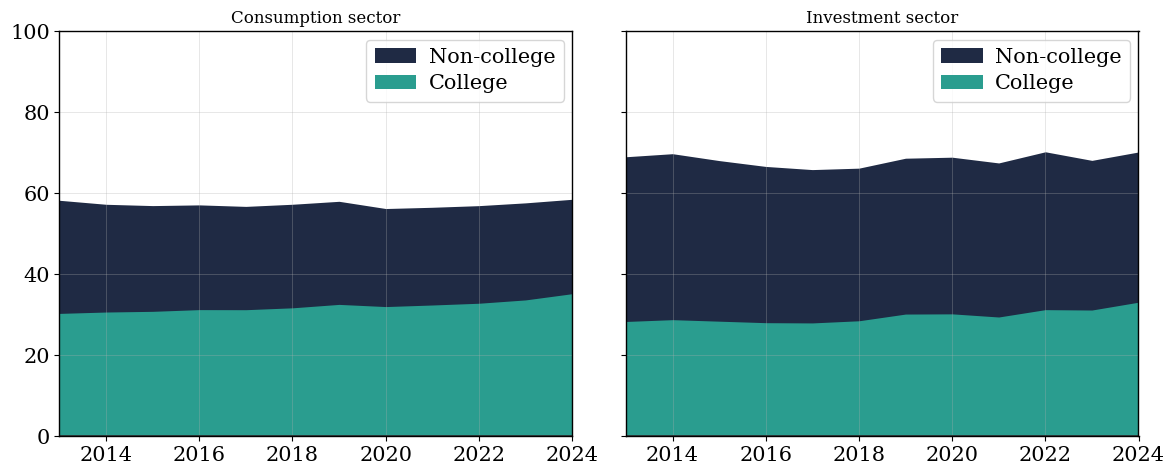

In [118]:
x = agg["TID"].to_numpy()

C_col = agg["LS_college_C"].to_numpy()  *100
C_non = agg["LS_noncol_C"].to_numpy()   *100
I_col = agg["LS_college_I"].to_numpy()  *100
I_non = agg["LS_noncol_I"].to_numpy()   *100

# if your series are in [0,1], uncomment:
# C_col, C_non, I_col, I_non = [s*100 for s in (C_col, C_non, I_col, I_non)]

# --- your vibe: crisp, minimal, crimson accent + neutral fills
fog   = "#E7E9EE"
steel = "#C9D2DF"
c_col = "#2A9D8F"   # college
c_non = "#1F2A44"   # noncollege


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

def pct(x, pos):  # y-axis formatter
    return f"{x:.0f}%"

ymax = np.nanmax([C_col + C_non, I_col + I_non])
ymax = float(np.ceil(max(ymax, 60) / 10) * 10)  # round up to nearest 10
ymax = min(max(ymax, 70), 100)                  # keep sane

for ax, col, non, panel_title in [
    (axes[0], C_col, C_non, "Consumption sector"),
    (axes[1], I_col, I_non, "Investment sector"),
]:
    top = col + non

    # background "total labor share" fill (neutral)
    ax.fill_between(x, 0, top, color=c_non, linewidth=0, label="Non-college")

    # college fill (crimson accent)
    ax.fill_between(x, 0, col, color=c_col, linewidth=0, label='College')

    # subtle baseline
    ax.axhline(0, color="0.2", linewidth=1.2)

    ax.set_title(panel_title, fontsize=12)
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, 100)
    
    # clean spines + ticks

    # minimalist grid (very faint)
    ax.grid(linewidth=0.6, alpha=0.35)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6))

    # in-panel labels (low-key)
    ax.legend()

# single figure title (also your style: understated)
plt.tight_layout()
plt.show()

In [119]:
# 1. rename
out = agg.rename(columns={
    "LS_college_C": "alpha2L",
    "LS_noncol_C" : "alpha1L",
    "LS_college_I": "beta2L",
    "LS_noncol_I" : "beta1L",
})

# 2. print
print(out.iloc[-2][["TID","alpha1L","alpha2L","beta1L","beta2L"]])

TID        2023.000000
alpha1L       0.239679
alpha2L       0.336729
beta1L        0.369555
beta2L        0.311783
Name: 10, dtype: float64


**Intuition:** *when merging to make the industry split, I loose six industries. This must result in the bias above that make both plots higher than the economy wide aggregate.*

In [120]:
# 1. compute weights within each year
df_e_slim["w_adj"] = (df_e_slim["GVA"] 
                     / df_e_slim.groupby(["TID"])["GVA"].transform("sum"))

# 4. labour shares as fractions
df_e_slim['labor_share'] /= 100
df_e_slim['type'] = df_e_slim['branche_code'].map(IO_parent_year.set_index('parent')['type'])

# 5. weighted labour shares per year
agg = (df_e_slim.groupby(["TID", "type"])
       .apply(lambda g: pd.Series({
           "LS": np.sum(g["w_adj"] * g["labor_share"]),
       }))
       .reset_index()
)

C:\Users\LinusLindquist\AppData\Local\Temp\ipykernel_11020\3922130256.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
